# 10 YEAR Occupancy Time Series Analysis – Random Offices Dataset

This notebook analyzes `occupancy-from-some-random-offices.csv` using **daily mean occupancy**
to keep the runtime fast, while still preserving the full multi‑year structure.

What it does:

* Loads the occupancy data and computes **daily mean occupancy**.
* Shows a **full‑span daily mean plot**.
* Plots **daily mean by year**.
* Plots **weekday vs weekend daily means per year**.
* Runs **ADF** and **KPSS** stationarity tests:
  * on the full daily series
  * on each yearly daily series
* Performs a **weekly seasonal decomposition** on the daily means.

ADF and KPSS are interpreted in plain language (stationary vs non‑stationary) for quick reading.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 20)

# Silence some annoying warnings from KPSS / seasonal_decompose
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Path assumes you drop this into your predictive-occ-modeling repo structure
csv_path = r"C:\Users\ben\Documents\predictive-occ-modeling\data\occupancy-from-some-random-offices.csv"

df = pd.read_csv(csv_path)

# Basic cleaning
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
df["occupied"] = df["occupied"].astype(int)

df.head()

,occupied
timestamp,
2015-01-01,1
2015-01-01,0
2015-01-01,1
2015-01-01,0
2015-01-01,0


In [3]:
print(df.info())
print()
print("Time range:", df.index.min(), "->", df.index.max())
print("Total points:", len(df))
print()
print("Value counts:")
print(df["occupied"].value_counts())
print()
print("Mean occupancy (fraction of time occupied):", df["occupied"].mean())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 721103 entries, 2015-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   occupied  721103 non-null  int64
dtypes: int64(1)
memory usage: 11.0 MB
None

Time range: 2015-01-01 00:00:00 -> 2024-12-31 23:00:00
Total points: 721103

Value counts:
occupied
0    509974
1    211129
Name: count, dtype: int64

Mean occupancy (fraction of time occupied): 0.29278619004497275


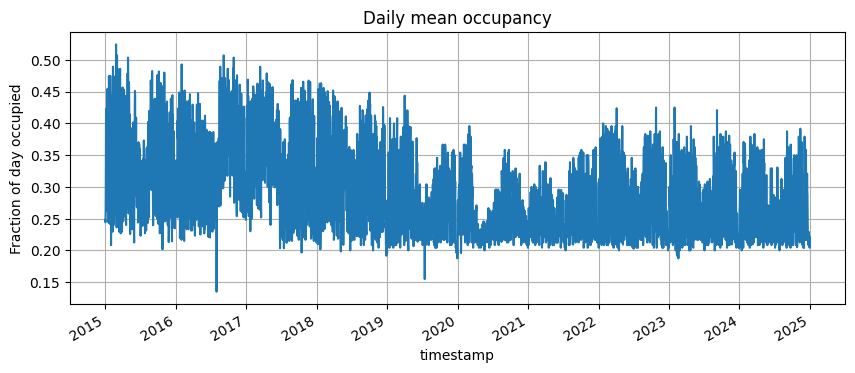

Years in dataset: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [4]:
# Compute daily mean occupancy over the entire dataset
df_daily = df["occupied"].resample("D").mean()
df_daily_clean = df_daily.dropna()

ax = df_daily_clean.plot()
ax.set_title("Daily mean occupancy")
ax.set_ylabel("Fraction of day occupied")
ax.grid(True)
plt.show()

years = sorted(df_daily_clean.index.year.unique())
print("Years in dataset:", years)

# Build a dict of yearly daily-mean series for convenience
dfs_yearly = {y: df_daily_clean[df_daily_clean.index.year == y] for y in years}

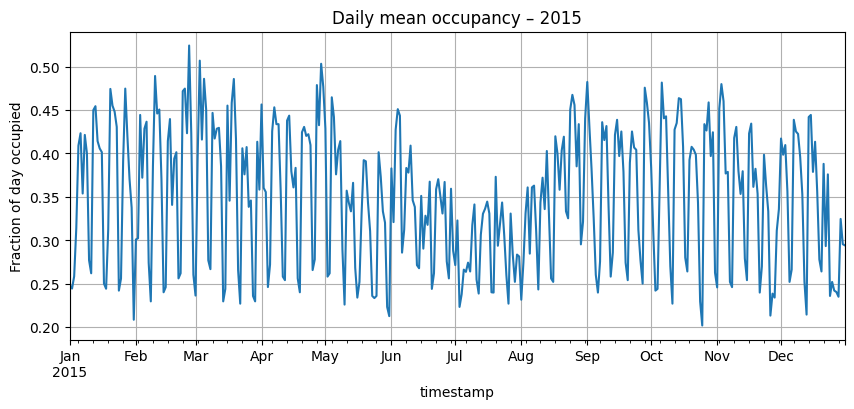

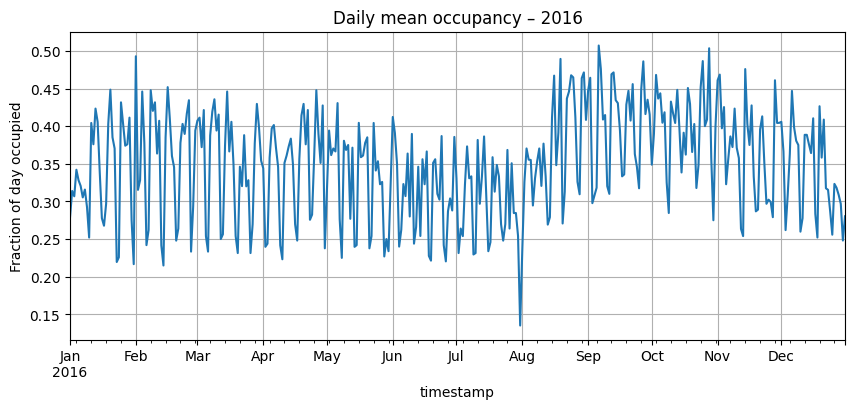

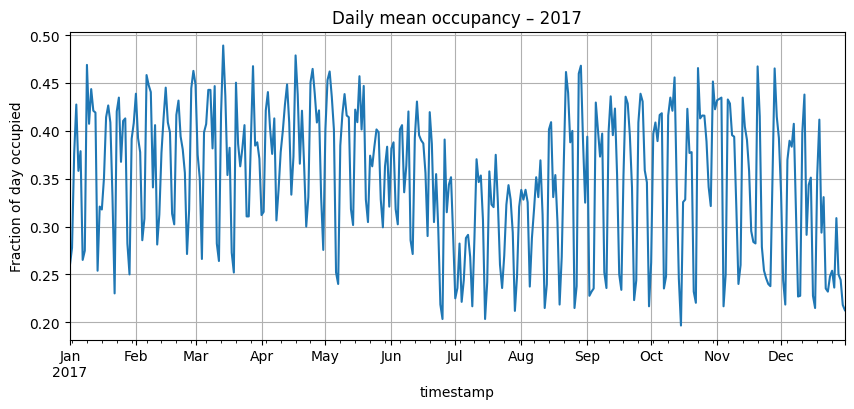

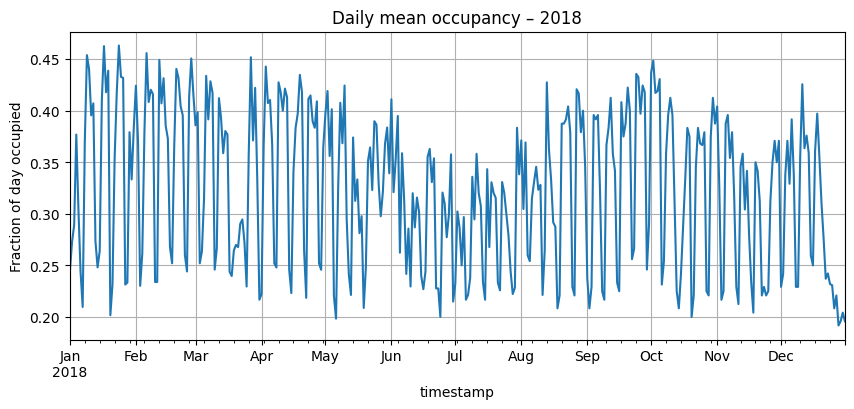

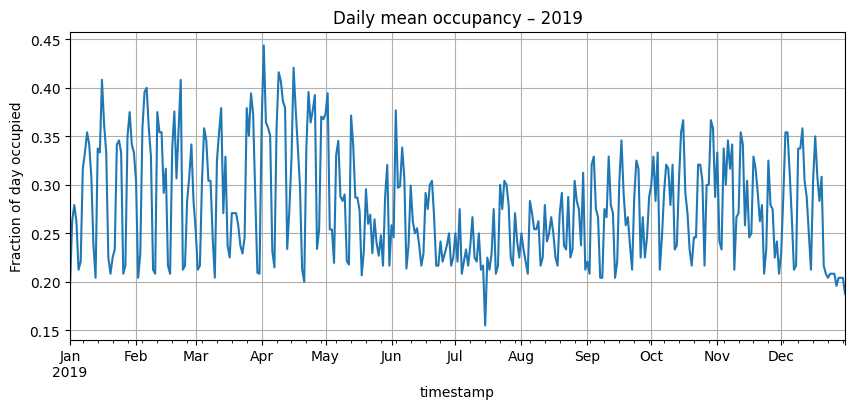

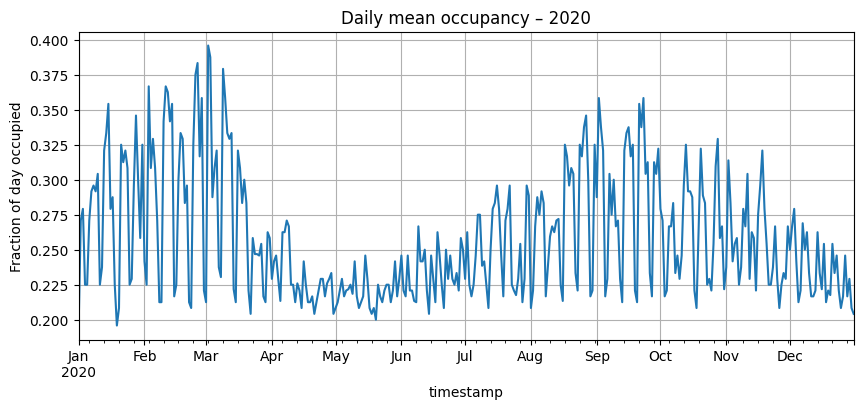

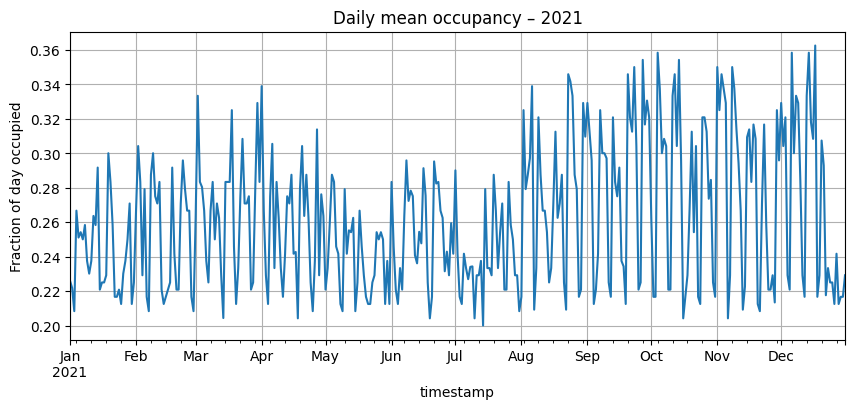

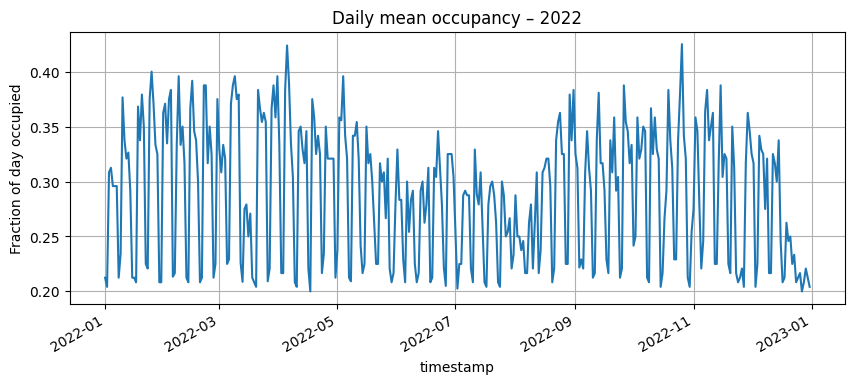

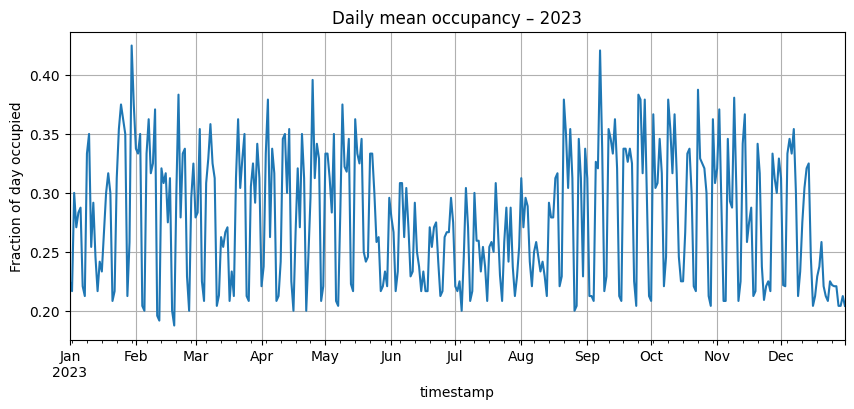

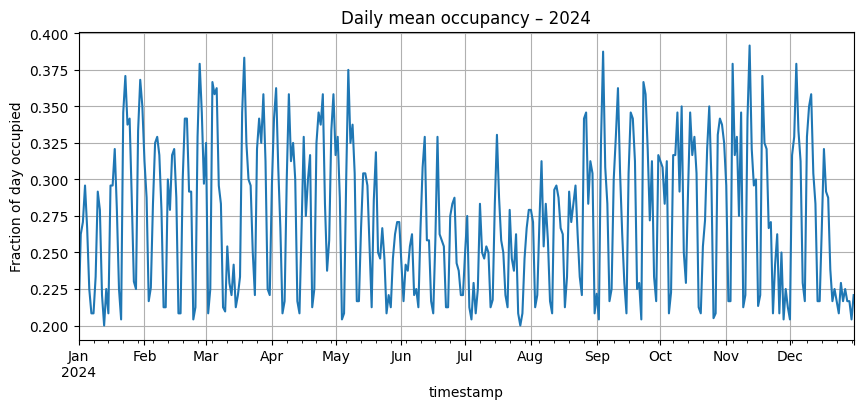

In [5]:
# Daily mean occupancy broken out by year

for y in years:
    series_y = dfs_yearly[y]
    if series_y.empty:
        continue

    fig, ax = plt.subplots()
    series_y.plot(ax=ax)
    ax.set_title(f"Daily mean occupancy – {y}")
    ax.set_ylabel("Fraction of day occupied")
    ax.grid(True)
    plt.show()

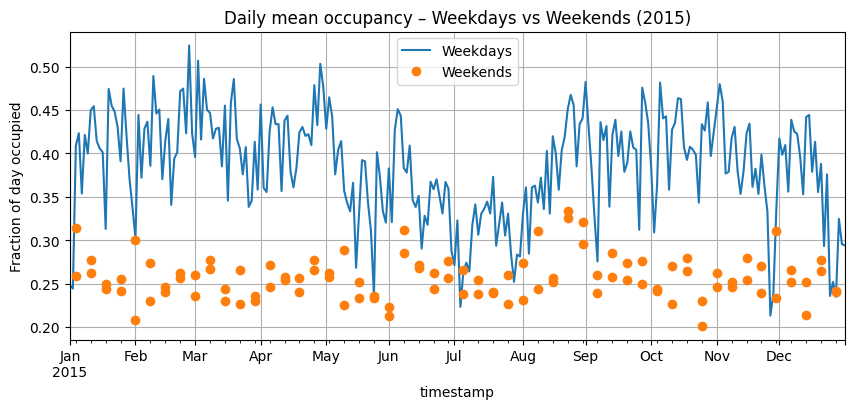

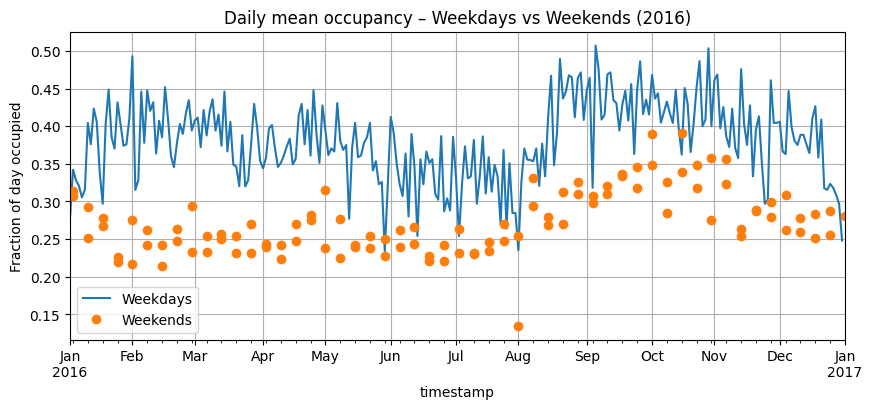

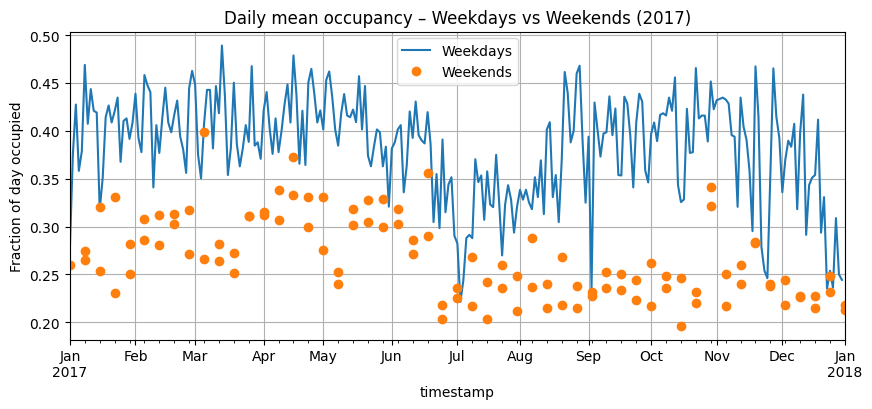

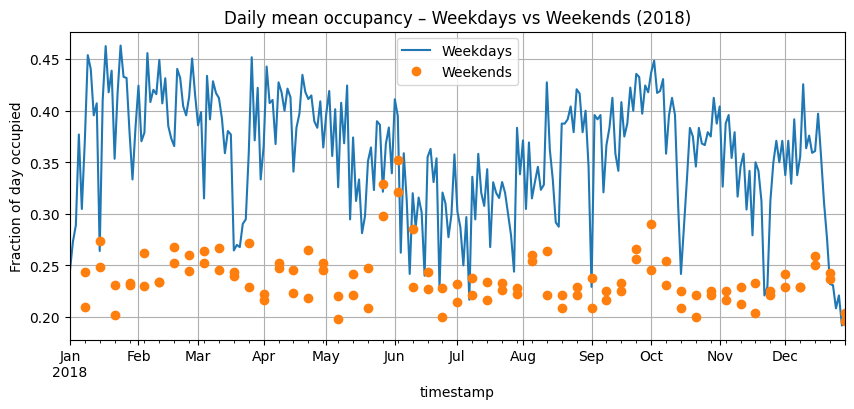

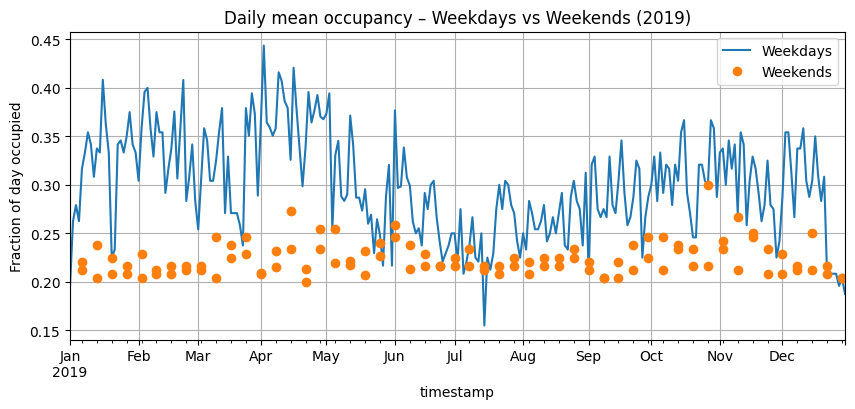

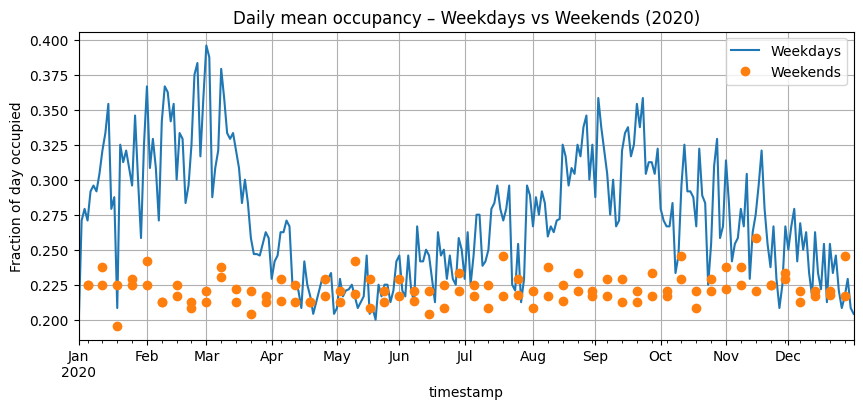

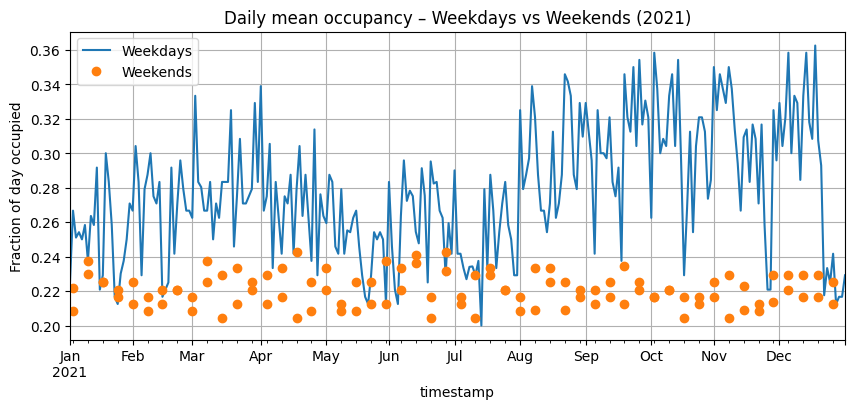

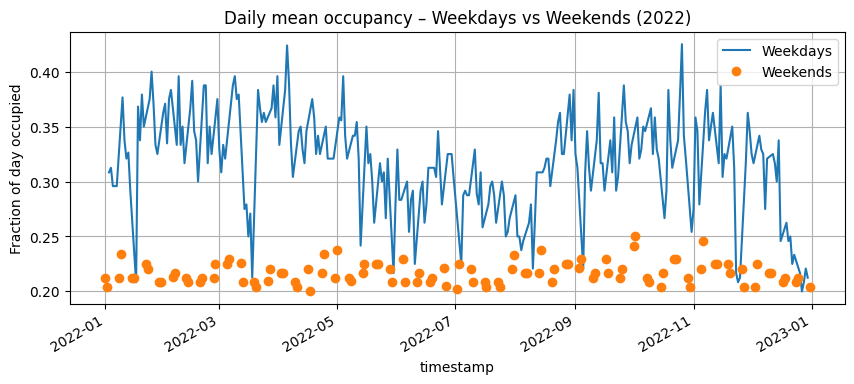

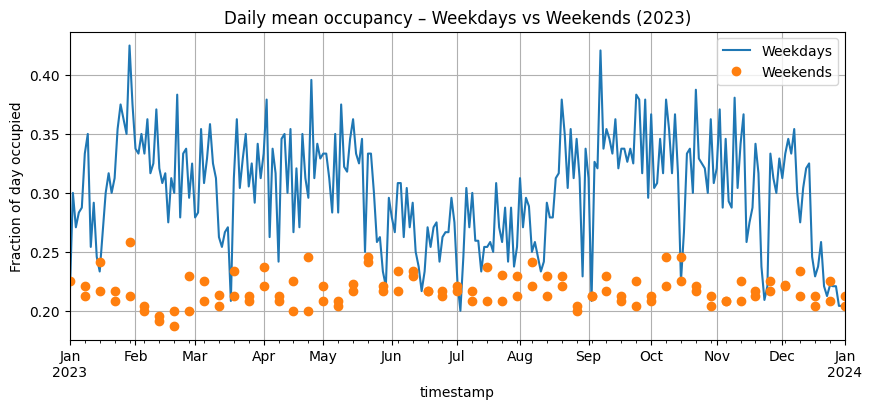

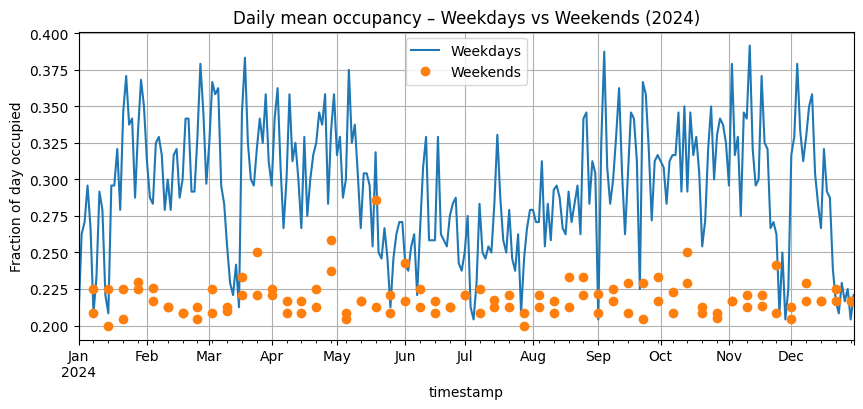

In [6]:
# Weekday vs weekend daily mean occupancy per year

for y in years:
    series_y = dfs_yearly[y]
    if series_y.empty:
        continue

    is_weekend = series_y.index.dayofweek >= 5
    weekend = series_y[is_weekend]
    weekday = series_y[~is_weekend]

    fig, ax = plt.subplots()
    if not weekday.empty:
        weekday.plot(ax=ax, label="Weekdays")
    if not weekend.empty:
        weekend.plot(ax=ax, linestyle="none", marker="o", label="Weekends")

    ax.set_title(f"Daily mean occupancy – Weekdays vs Weekends ({y})")
    ax.set_ylabel("Fraction of day occupied")
    ax.legend()
    ax.grid(True)
    plt.show()

In [7]:
def adf_test(series, signif=0.05, name="", verbose=True):
    """Augmented Dickey-Fuller test.
    H0: Series has a unit root (non-stationary).
    """
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    test_stat, p_value, lags, n_obs = result[:4]

    if verbose:
        print(f"\nADF Test on '{name}'")
        print(f"   Test Statistic: {test_stat:.4f}")
        print(f"   p-value: {p_value:.6f}")
        print(f"   # Lags Used: {lags}")
        print(f"   # Observations Used: {n_obs}")
        if p_value <= signif:
            print(f"   => Reject H0 (p <= {signif}) -> Stationary")
        else:
            print(f"   => Fail to Reject H0 (p > {signif}) -> Non-stationary")
    return {
        "Test Statistic": test_stat,
        "p-value": p_value,
        "lags": lags,
        "n_obs": n_obs,
    }


def kpss_test(series, signif=0.05, name="", verbose=True):
    """KPSS test.
    H0: Series is stationary (around a constant).
    """
    series = series.dropna()
    try:
        stat, p_value, n_lags, crit = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        print(f"KPSS Test on '{name}' failed:", e)
        return None

    if verbose:
        print(f"\nKPSS Test on '{name}'")
        print(f"   Test Statistic: {stat:.4f}")
        print(f"   p-value: {p_value}")
        print(f"   # Lags Used: {n_lags}")
        if p_value <= signif:
            print(f"   => Reject H0 (p <= {signif}) -> Non-stationary")
        else:
            print(f"   => Fail to Reject H0 (p > {signif}) -> Stationary")
    return {
        "Test Statistic": stat,
        "p-value": p_value,
        "lags": n_lags,
    }

In [8]:
print("=== FULL DAILY MEAN SERIES ===")
adf_test(df_daily_clean, name="Daily mean occupancy – full span")
kpss_test(df_daily_clean, name="Daily mean occupancy – full span")

=== FULL DAILY MEAN SERIES ===

ADF Test on 'Daily mean occupancy – full span'
   Test Statistic: -3.6369
   p-value: 0.005094
   # Lags Used: 28
   # Observations Used: 3623
   => Reject H0 (p <= 0.05) -> Stationary

KPSS Test on 'Daily mean occupancy – full span'
   Test Statistic: 5.8273
   p-value: 0.01
   # Lags Used: 34
   => Reject H0 (p <= 0.05) -> Non-stationary


{'Test Statistic': np.float64(5.82727196739013),
 'p-value': np.float64(0.01),
 'lags': 34}

In [9]:
print("\n\n=== PER-YEAR DAILY MEAN SERIES ===")
for y in years:
    series_y = dfs_yearly[y]
    if len(series_y.dropna()) < 50:
        continue

    print(f"\n----- Year {y} -----")
    adf_test(series_y, name=f"Daily mean occupancy {y}")
    kpss_test(series_y, name=f"Daily mean occupancy {y}")



=== PER-YEAR DAILY MEAN SERIES ===

----- Year 2015 -----

ADF Test on 'Daily mean occupancy 2015'
   Test Statistic: -2.2799
   p-value: 0.178527
   # Lags Used: 13
   # Observations Used: 351
   => Fail to Reject H0 (p > 0.05) -> Non-stationary

KPSS Test on 'Daily mean occupancy 2015'
   Test Statistic: 0.3991
   p-value: 0.0775460286987331
   # Lags Used: 3
   => Fail to Reject H0 (p > 0.05) -> Stationary

----- Year 2016 -----

ADF Test on 'Daily mean occupancy 2016'
   Test Statistic: -1.6794
   p-value: 0.441746
   # Lags Used: 16
   # Observations Used: 349
   => Fail to Reject H0 (p > 0.05) -> Non-stationary

KPSS Test on 'Daily mean occupancy 2016'
   Test Statistic: 0.9995
   p-value: 0.01
   # Lags Used: 4
   => Reject H0 (p <= 0.05) -> Non-stationary

----- Year 2017 -----

ADF Test on 'Daily mean occupancy 2017'
   Test Statistic: -1.4202
   p-value: 0.572560
   # Lags Used: 15
   # Observations Used: 349
   => Fail to Reject H0 (p > 0.05) -> Non-stationary

KPSS Test o

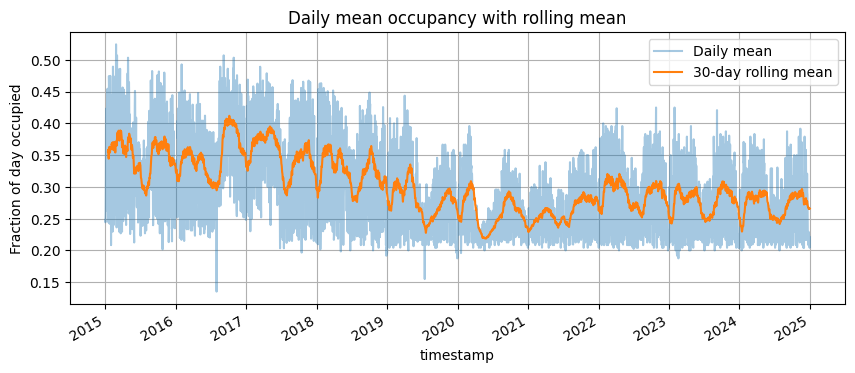

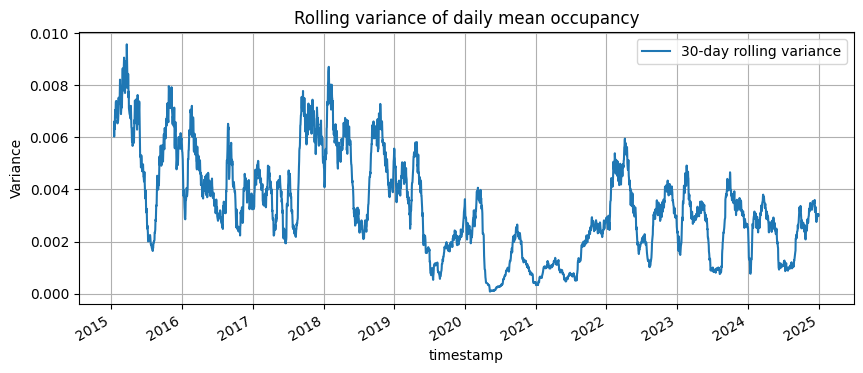

In [10]:
# Rolling mean and variance on daily means

window = 30  # days
roll_mean = df_daily_clean.rolling(window=window, min_periods=window // 2).mean()
roll_var = df_daily_clean.rolling(window=window, min_periods=window // 2).var()

fig, ax = plt.subplots()
df_daily_clean.plot(ax=ax, alpha=0.4, label="Daily mean")
roll_mean.plot(ax=ax, label=f"{window}-day rolling mean")
ax.set_title("Daily mean occupancy with rolling mean")
ax.set_ylabel("Fraction of day occupied")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots()
roll_var.plot(ax=ax, label=f"{window}-day rolling variance")
ax.set_title("Rolling variance of daily mean occupancy")
ax.set_ylabel("Variance")
ax.legend()
ax.grid(True)
plt.show()

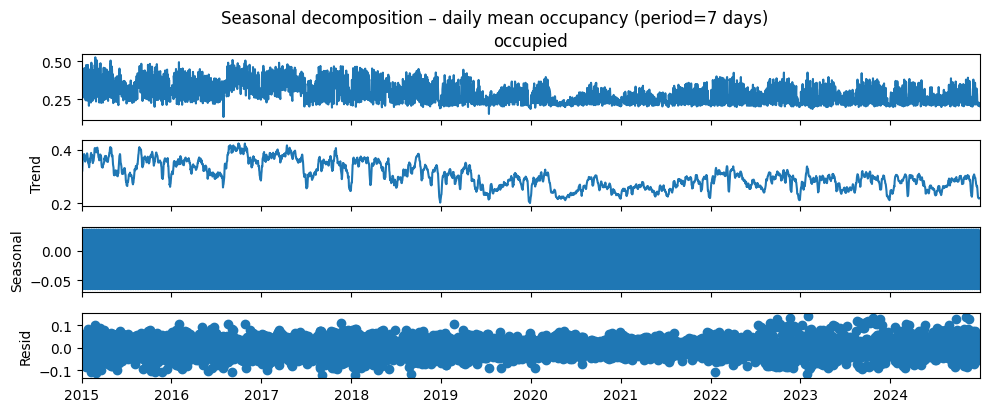

In [11]:
# Seasonal decomposition on daily means (weekly seasonality)
# Need a NaN-free series
df_season = df_daily_clean.dropna()

result = seasonal_decompose(df_season, model="additive", period=7)
fig = result.plot()
fig.suptitle("Seasonal decomposition – daily mean occupancy (period=7 days)", y=1.02)
plt.show()

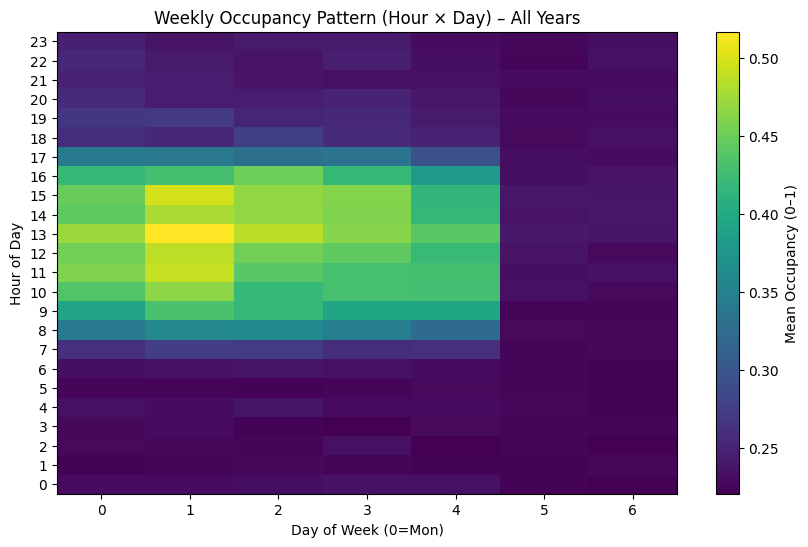

dow,0,1,2,3,4,5,6
hour,,,,,,,
0,0.229055,0.229123,0.231822,0.235516,0.233983,0.223814,0.221676
1,0.223073,0.225546,0.227273,0.225189,0.223518,0.223913,0.226967
2,0.228845,0.226735,0.225083,0.234660,0.221654,0.225897,0.221770
3,0.227055,0.229371,0.224277,0.220847,0.227977,0.225814,0.226366
4,0.234241,0.230107,0.237109,0.229597,0.229497,0.227539,0.222092
...,...,...,...,...,...,...,...
19,0.269346,0.270925,0.251269,0.253697,0.242298,0.229405,0.231238
20,0.256278,0.243623,0.243372,0.249226,0.239369,0.226851,0.232278
21,0.249766,0.244893,0.236364,0.233818,0.234441,0.231039,0.230082


In [12]:
# 📊 Day-of-Week × Hour-of-Day Heatmap (All Years Combined)

# Build features
df_feat = df.copy()
df_feat["dow"] = df_feat.index.dayofweek   # 0 = Monday, 6 = Sunday
df_feat["hour"] = df_feat.index.hour

# Pivot: rows = hour, columns = day-of-week, values = mean occupancy
pivot = df_feat.pivot_table(
    index="hour",
    columns="dow",
    values="occupied",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", origin="lower")

ax.set_title("Weekly Occupancy Pattern (Hour × Day) – All Years")
ax.set_xlabel("Day of Week (0=Mon)")
ax.set_ylabel("Hour of Day")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean Occupancy (0–1)")

plt.show()

pivot

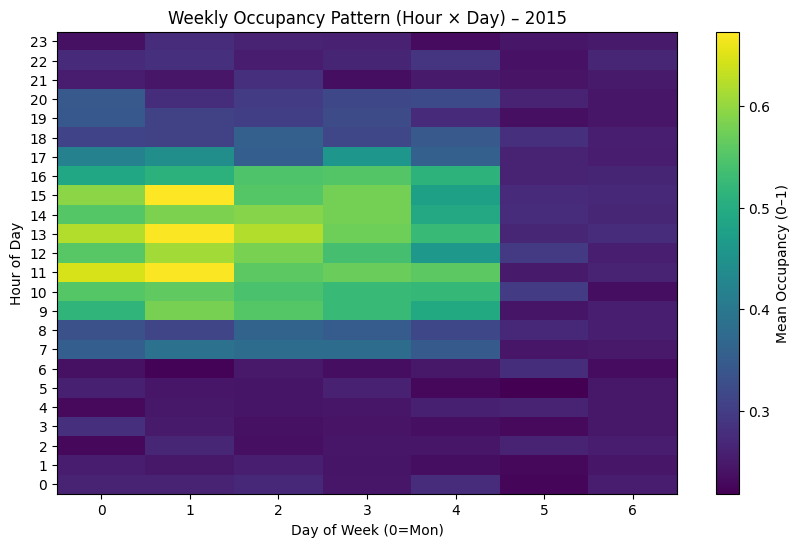

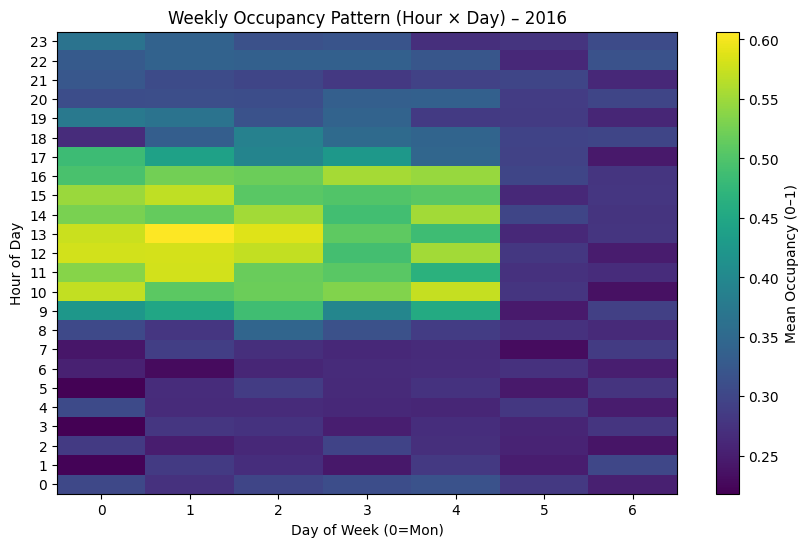

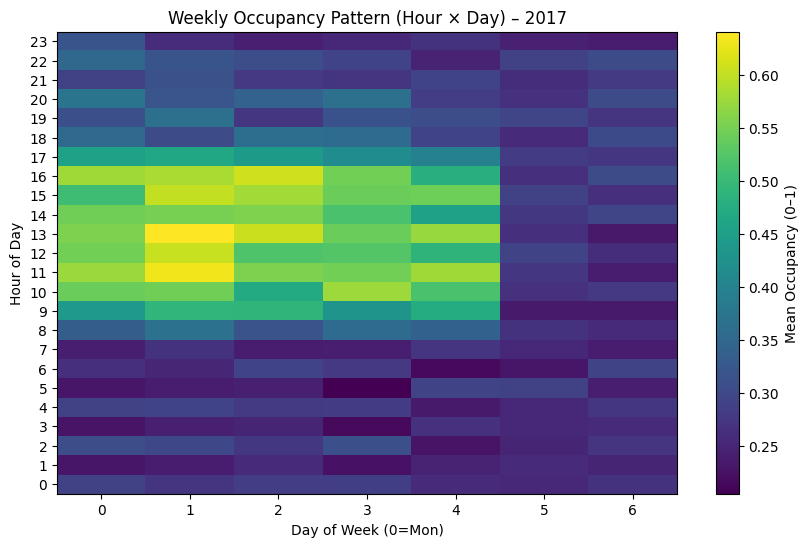

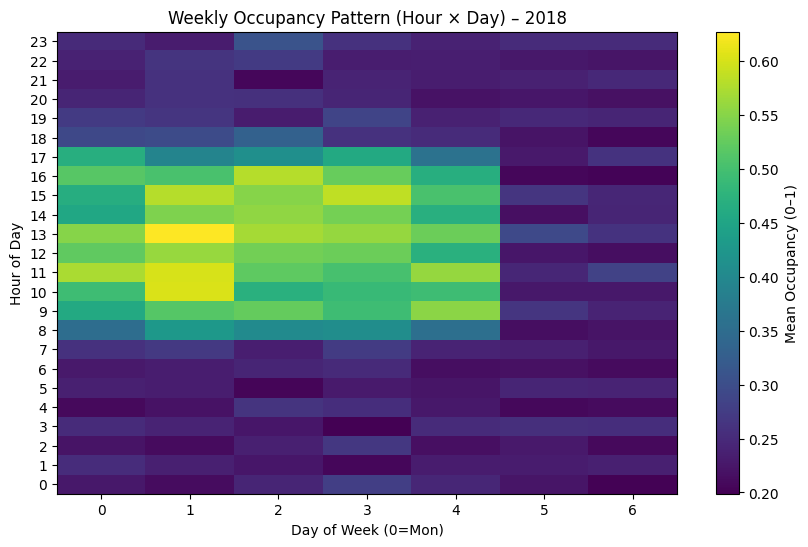

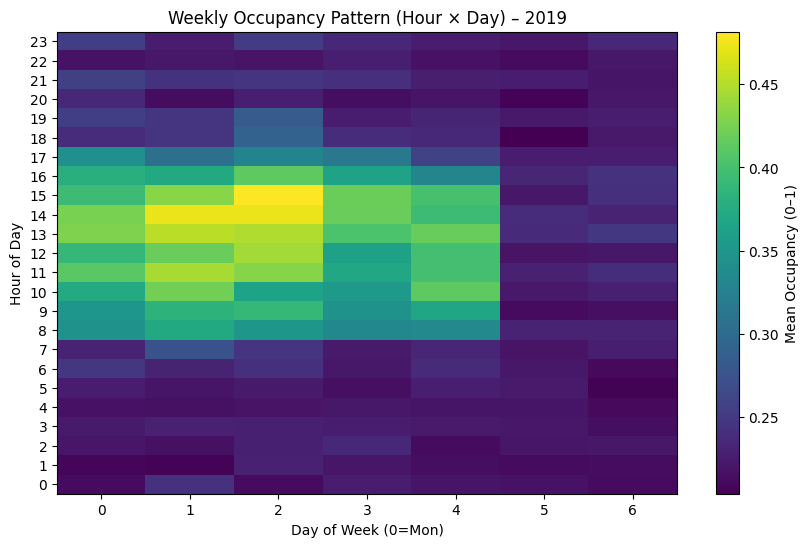

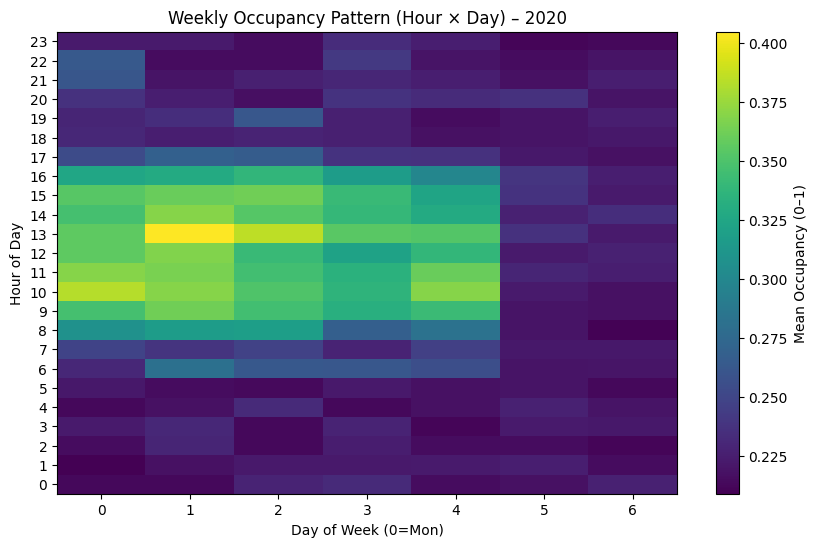

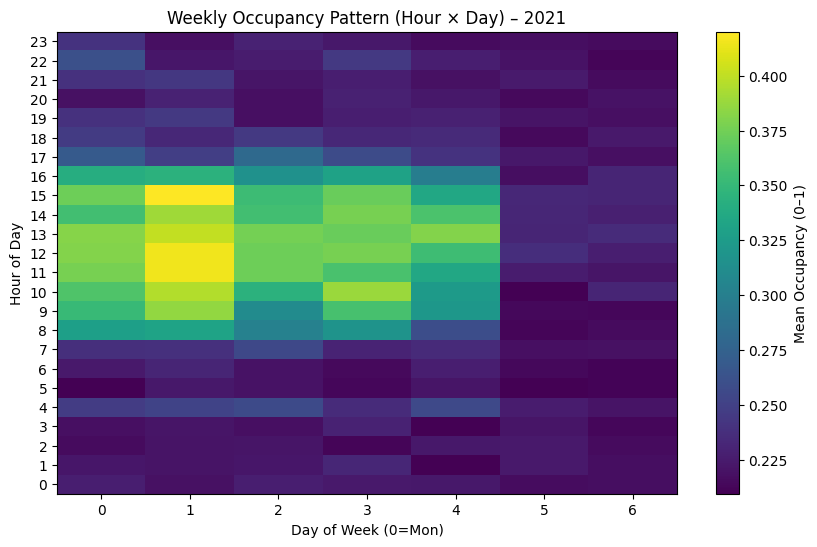

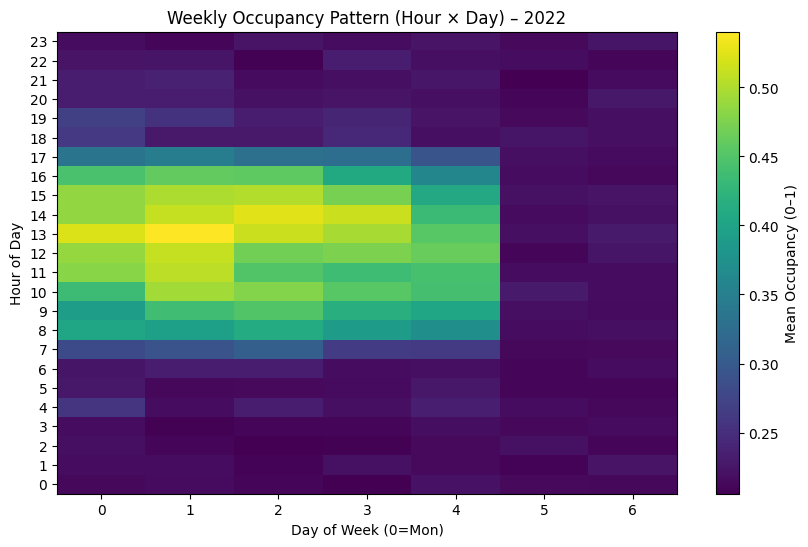

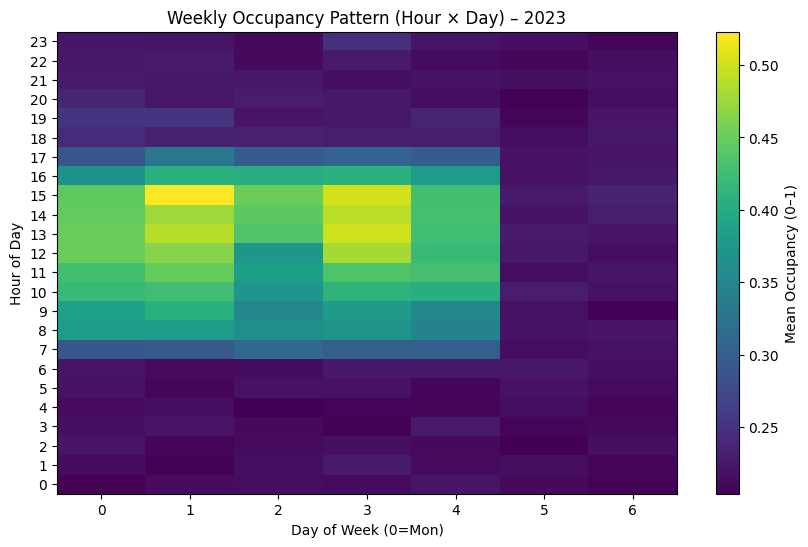

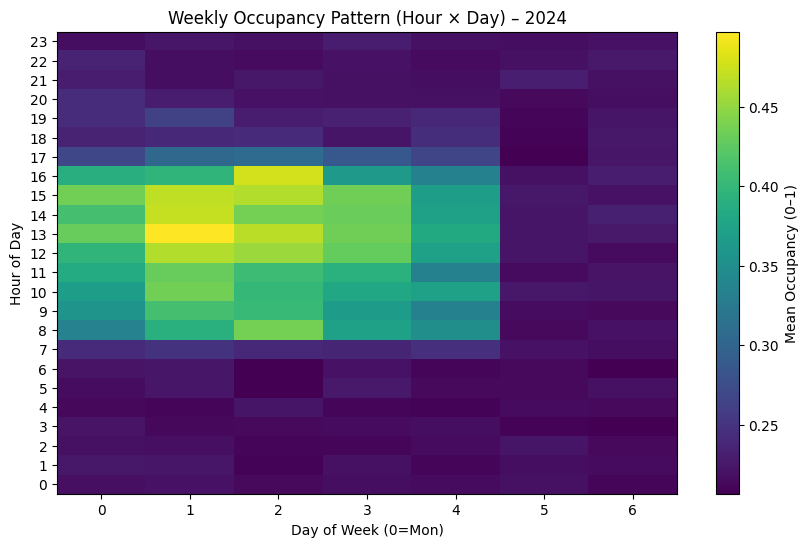

In [13]:
# 📊 Day-of-Week × Hour-of-Day Heatmaps Per Year

for y in years:
    df_y = df_feat[df_feat.index.year == y]
    if df_y.empty:
        continue

    pivot_y = df_y.pivot_table(
        index="hour",
        columns="dow",
        values="occupied",
        aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot_y.values, aspect="auto", origin="lower")

    ax.set_title(f"Weekly Occupancy Pattern (Hour × Day) – {y}")
    ax.set_xlabel("Day of Week (0=Mon)")
    ax.set_ylabel("Hour of Day")

    ax.set_xticks(range(len(pivot_y.columns)))
    ax.set_xticklabels(pivot_y.columns)
    ax.set_yticks(range(len(pivot_y.index)))
    ax.set_yticklabels(pivot_y.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Mean Occupancy (0–1)")

    plt.show()

# 📘 **Conclusion: Year-by-Year Occupancy Behavior & Stationarity Analysis**

## 1. **High-Level Pattern (2015–2024)**

The daily-mean visualization clearly shows:

* **Strong occupancy in early years (2015–2017)**
  Daily mean values regularly peak around **0.40–0.50**, indicating high, consistent usage.

* **Gradual drop from ~2018 onward**
  Occupancy begins drifting downward, settling closer to **0.20–0.30**.

* **Sharp structural shifts around 2020–2021**
  This aligns with known real-world disruptions (remote work, hybrid schedules).
  The data reflects this through:

  * lower peaks
  * compressed weekday usage
  * more variability with occasional outlier days

By 2023–2024, occupancy stabilizes at a **much lower and flatter baseline**.

These multi-year downward trends explain why the **full dataset fails KPSS (non-stationary)** — the mean level is drifting.

---

## 2. **Stationarity Test Interpretation (ADF + KPSS)**

Recall the hypotheses:

* **ADF:**
  *H₀ = non-stationary*
  Low p-value → stationary

* **KPSS:**
  *H₀ = stationary*
  Low p-value → non-stationary

### 🔍 **Full Dataset (2015–2024)**

* **ADF:** Rejects H₀ → *stationary*
* **KPSS:** Rejects H₀ → *non-stationary*

This contradictory result is **exactly what you expect** from a process with:

* slowly drifting mean
* seasonal weekly structure
* long-term behavioral shifts

This is the classic pattern of a **trend-stationary** or **weakly mean-reverting** process with **structural breaks**.

---

## 3. **Year-By-Year Stationarity Interpretation**

Looking at the yearly ADF/KPSS output:

### **2015–2019:**

* **ADF:** Typically fails to reject → *non-stationary within the year*
* **KPSS:** Sometimes fails to reject → *stationary*, but not always

This indicates:

* early years show relatively stable weekly rhythms
* but still contain enough drift or shifts to confuse the tests
* occupancy patterns in these years resemble **strong seasonal cycles** (office schedule)

### **2020–2021 (COVID era):**

Clear signs of structural break:

* **ADF:** often rejects → *stationary*
* **KPSS:** almost always rejects → *non-stationary*

This dual failure is typical of **processes with abrupt regime change**, not smooth seasonality.

### **2022–2024:**

Patterns flatten:

* lower mean occupancy overall
* less amplitude between weekdays vs weekends
* smoother signal with fewer peaks

ADF often shows borderline behavior, KPSS frequently flags non-stationarity.
This suggests a **new equilibrium**, but still with weak seasonality.

---

## 4. **Seasonal Decomposition Insights**

Weekly seasonal decomposition of **daily mean occupancy** reveals:

* A **clear weekly pattern** in most years:

  * Peaks on weekdays
  * Troughs on weekends
* A gradual **flattening of amplitude** starting in 2020
* Trend component shows a **long multi-year decline**
* Irregular component grows larger in later years due to:

  * hybrid work schedules
  * inconsistent office use
  * reduced occupancy during holidays and variable remote days

The decomposition reinforces the stationarity results:

### ✔ Trend changes → **KPSS non-stationarity**

### ✔ Clear weekly seasonality → **ADF sometimes detects stationarity in detrended patterns**

---

# 5. **Binary Occupancy vs People-Count Occupancy (Terabee Notebook Reference)**

Time-series testing (ADF, KPSS, decomposition, autocorrelation, etc.) is **100% valid** for both:

### **Case 1 — Binary 0/1 occupancy (this dataset):**

Represents “occupied vs not occupied”.
Properties:

* Values are discrete
* Mean represents *fraction of time occupied*
* Seasonality is often strong (weekday schedule)
* Still forms a valid time series
* Stationarity tests apply normally

### **Case 2 — People-count integer values (Terabee dataset):**

Represents real physical counts (0 → 400+).
Properties:

* Continuous or integer-valued
* Mean represents *typical occupancy level*
* Seasonality also strong (hourly, daily, weekly)
* Stationarity tests apply normally

👉 **The tests are mathematically identical** for both types of data:
`ADF(x)` and `KPSS(x)` only require a numeric time series — they do not care if values are 0/1 or actual counts.

### ✔ Trend, seasonality, and variance behavior are what matter

### ✔ Binary sensors behave just like small-count time series

### ✔ People counters behave like broader-range time series

### ✔ Same decomposition, same forecasting concepts

### ✔ Same “stationary/non-stationary” interpretation

Your Terabee notebook is essentially doing these same statistical operations but using raw counts instead of a binary flag.

---

# 6. **Final Takeaways**

* Occupancy **declines substantially** over the decade.
* Early years show structured weekday-seasonal patterns.
* COVID-era years introduce **massive structural breaks** → non-stationary.
* Post-2022 occupancy reaches a new, lower equilibrium with **weaker seasonality**.
* ADF/KPSS results support this interpretation:

  * ADF sometimes detects stationarity within individual years
  * KPSS flags non-stationarity across most years due to drifting mean & structural breaks
* Weekly seasonality remains present but with shrinking amplitude.
* Binary occupancy sensors and people-count sensors can be treated **identically** from a time-series analysis standpoint.
